In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

#분류 -> 각 클래스가 비율이 비슷한지?
#증강(Augmentation) -> 데이터를 임의 생성
#**불균형 데이터셋을 다룰 때 사용하는 오버샘플링 기법 라이브러리
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
train_path = '/content/drive/MyDrive/블루문/cancer_train.csv'
test_path = '/content/drive/MyDrive/블루문/cancer_test.csv'
submission = '/content/drive/MyDrive/블루문/cancer_submission.csv'

In [11]:
train = pd.read_csv(train_path)

X = train.drop(columns=['ID', 'Cancer'])
Y = train['Cancer']

In [13]:
#범주형 데이터(카테고리컬)를 어떻게 잘 반영할 것인가?
#시각화 코드**
#상관관계 그래프 (Age,Nodule_Size,TSH_Result,T4_Result,T3_Result)
X.head()

,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result
0,80,M,CHN,ASN,Positive,Exposed,Sufficient,Non-Smoker,Not Obese,No,0.650355,2.784735,6.744603,2.575820
1,37,M,NGA,ASN,Positive,Unexposed,Sufficient,Smoker,Obese,No,2.950430,0.911624,7.303305,2.505317
2,71,M,CHN,MDE,Positive,Unexposed,Sufficient,Non-Smoker,Not Obese,Yes,2.200023,0.717754,11.137459,2.381080
3,40,F,IND,HSP,Negative,Unexposed,Sufficient,Non-Smoker,Obese,No,3.370796,6.846380,10.175254,0.753023
4,53,F,CHN,CAU,Negative,Unexposed,Sufficient,Non-Smoker,Not Obese,No,4.230048,0.439519,7.194450,0.569356


시각화로 두 클래스의 분포 차이 확인

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

#Y축 = 양성, 음성 클래스의 카운팅 값
#X축 = 양성, 음성
unique_count = Y.unique()
counts = Y.value_counts()
print(counts)

Cancer
0    76700
1    10459
Name: count, dtype: int64


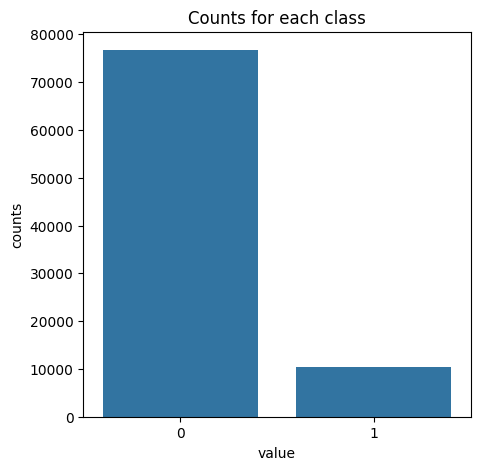

In [20]:
plt.figure(figsize=(5, 5))

sns.barplot(x=[0, 1], y=counts)
plt.title('Counts for each class')
plt.xlabel('value')
plt.ylabel('counts')
plt.show()

In [23]:
#인코딩!
#'dtype'이 -> 'object'
categori_feature = [c for c in X.columns if X[c].dtype=='object']

for cate in categori_feature:
  #라벨 인코딩을 통해 문자 데이터를 숫자로 변형
  le = LabelEncoder()
  X[cate] = le.fit_transform(X[cate])

In [25]:
X.head()

,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result
0,80,1,1,1,1,0,1,0,0,0,0.650355,2.784735,6.744603,2.575820
1,37,1,7,1,1,1,1,1,1,0,2.950430,0.911624,7.303305,2.505317
2,71,1,1,4,1,1,1,0,0,1,2.200023,0.717754,11.137459,2.381080
3,40,0,4,3,0,1,1,0,1,0,3.370796,6.846380,10.175254,0.753023
4,53,0,1,2,0,1,1,0,0,0,4.230048,0.439519,7.194450,0.569356


In [26]:
#팀원들끼리 랜덤 번호를 다르게 해서 각자 다른 셋을 만들어 봄
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(X, Y)

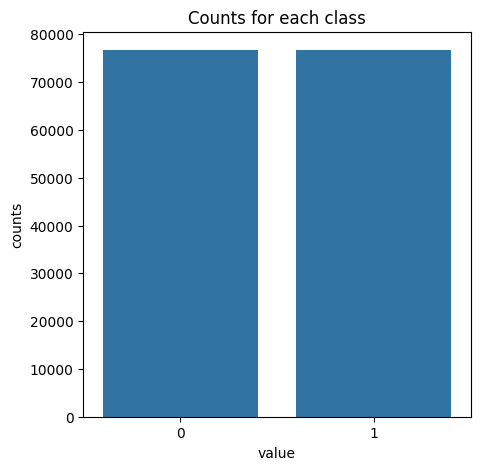

In [28]:
counts = y_train.value_counts()

plt.figure(figsize=(5, 5))

sns.barplot(x=[0, 1], y=counts)
plt.title('Counts for each class')
plt.xlabel('value')
plt.ylabel('counts')
plt.show()

In [29]:
#머신러닝 모델에 넣고 훈련시키기
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## 예측

- test.csv를 가져와서 확인

In [39]:
test_df = pd.read_csv(test_path)
test_df = test_df.drop(columns=['ID'])

In [40]:
# train데이터셋에 해준 전처리를 -> test에도 동일하게 적용
#여러번 테스트할 때 전처리를 한번에 진행할 수 있도록.
def preprocessing(dataframe):

  #인코딩
  categori_feature = [c for c in dataframe.columns if dataframe[c].dtype=='object']
  for cate in categori_feature:

    #라벨 인코딩을 통해 문자 데이터를 숫자로 변형
    le = LabelEncoder()
    dataframe[cate] = le.fit_transform(dataframe[cate])

  return dataframe

In [41]:
real_test = preprocessing(test_df)
real_test.head()

,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result
0,53,1,7,2,0,1,1,0,0,0,2.940678,6.434501,9.227958,2.733846
1,46,1,6,4,0,1,0,1,1,0,3.450129,4.729535,5.937664,0.775012
2,78,0,4,1,0,0,1,0,1,0,4.680720,5.663475,10.455964,1.259896
3,69,0,6,2,0,1,1,0,0,0,4.280588,7.473752,8.785335,2.826138
4,77,0,6,2,1,1,1,0,1,0,3.380094,7.099987,8.737063,3.453563


In [42]:
#진짜 제출할 test를 예측
test_result = xgb.predict(test_df)

In [43]:
test_result

array([0, 0, 1, ..., 0, 0, 0])

제출 포맷으로 변경

In [38]:
submission = pd.read_csv(submission)
submission.head()

,ID,Cancer
0,TEST_00000,0
1,TEST_00001,0
2,TEST_00002,0
3,TEST_00003,0
4,TEST_00004,0


In [46]:
submission['Cancer'] = test_result

In [45]:
submission.head()

,ID,Cancer
0,TEST_00000,0
1,TEST_00001,0
2,TEST_00002,1
3,TEST_00003,1
4,TEST_00004,0


In [47]:
#서브미션 데이터프레임을 나의 구글 드라이브로 저장
submission.to_csv('/content/drive/MyDrive/cancer_base.csv', index=False)

특정 열에 빈도수 기반 인코딩 적용

In [48]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00


In [49]:
import category_encoders as ce

In [51]:
frequenecy_encoded = x_train['Country'].value_counts(normalize=True)
x_train['Country'] = x_train['Country'].map(frequenecy_encoded)
x_train.head()

,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result
0,80,1,0.138044,1,1,0,1,0,0,0,0.650355,2.784735,6.744603,2.575820
1,37,1,0.151675,1,1,1,1,1,1,0,2.950430,0.911624,7.303305,2.505317
2,71,1,0.138044,4,1,1,1,0,0,1,2.200023,0.717754,11.137459,2.381080
3,40,0,0.238325,3,0,1,1,0,1,0,3.370796,6.846380,10.175254,0.753023
4,53,0,0.138044,2,0,1,1,0,0,0,4.230048,0.439519,7.194450,0.569356


In [52]:
# train데이터셋에 해준 전처리를 -> test에도 동일하게 적용
# 여러번 테스트할 때 전처리를 한번에 진행할 수 있도록.
def preprocessing(dataframe):

  # 인코딩
  categori_feature = [c for c in dataframe.columns if dataframe[c].dtype=='object']
  for cate in categori_feature:

    # 라벨 인코딩을 통해 문자 데이터를 숫자로 변형
    le = LabelEncoder()
    dataframe[cate] = le.fit_transform(dataframe[cate])

  # Country 열에 대한 빈도수 인코딩(프리퀸시 인코딩)
  frequency = dataframe['Country'].value_counts(normalize=True)
  dataframe['Country'] = dataframe['Country'].map(frequency)

  return dataframe

In [53]:
real_test.head()

,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result
0,53,1,7,2,0,1,1,0,0,0,2.940678,6.434501,9.227958,2.733846
1,46,1,6,4,0,1,0,1,1,0,3.450129,4.729535,5.937664,0.775012
2,78,0,4,1,0,0,1,0,1,0,4.680720,5.663475,10.455964,1.259896
3,69,0,6,2,0,1,1,0,0,0,4.280588,7.473752,8.785335,2.826138
4,77,0,6,2,1,1,1,0,1,0,3.380094,7.099987,8.737063,3.453563


In [54]:
real_test = preprocessing(real_test)

In [57]:
#모델 재정의
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
new_result = xgb.predict(real_test)

submission['Cancer'] = new_result
submission.to_csv('/content/new_try1.csv', index=False)